In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from cmcrameri import cm
import seaborn as sns
import re

plt.style.use('./libs/notebookstyle_aps.mplstyle')

%load_ext autoreload
%autoreload 2

In [2]:
dfq = pd.read_csv('./QNN_results/QNN_r2.txt', header =0, index_col = None)

def parse_config(s):
    match = re.match(r"(\d+)qubits_circuit_([a-zA-Z]+)_([a-zA-Z]+)_freq(\d+)enc_(\d+)dec_([a-zA-Z]+)", s)
    if match:
        qubits, enc_angles, angles, n_enc, n_dec,  entanglement = match.groups()
        return int(qubits), int(n_enc), int(n_dec), entanglement, angles, enc_angles
    return None, None, None, None

dfq[['n_qubits', 'n_enc', 'n_dec', 'entanglement','angles','enc_angles']] = dfq['model_name'].apply(
    lambda x: pd.Series(parse_config(x))
)

dfq['nonlocal'] = (dfq.entanglement == 'nonlocal')*1.
dfq['n_params'] = dfq.n_qubits*(dfq.n_enc + dfq.n_dec)*dfq.angles.apply(lambda s: len(s)) + dfq.n_qubits*dfq.n_enc*dfq.enc_angles.apply(lambda s: len(s))

In [3]:
dfq = dfq.reset_index()
key_map = {str(k): i for i, k in enumerate(np.unique(dfq.key.values))}
dfq["key_id"] = dfq["key"].astype(str).map(key_map)

### Figure with Overview of validation R² for SI

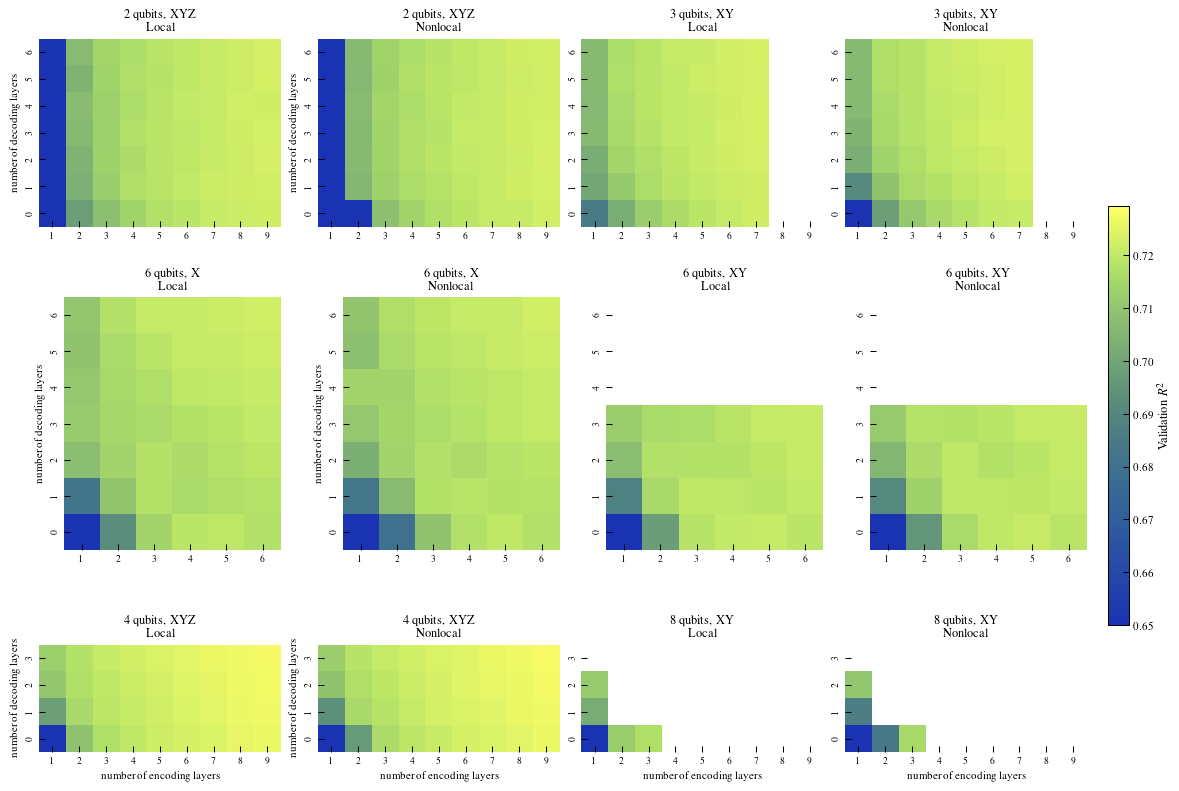

In [4]:
fig, axs = plt.subplots(
    3, 4,
    figsize=(11.69, 8.27),
    constrained_layout=True
)

configs = [
    dict(n_qubits=2, enc_angles="XYZ", label="2 qubits, XYZ"),
    dict(n_qubits=3, enc_angles="XY",  label="3 qubits, XY"),

    dict(n_qubits=6, enc_angles="X",   label="6 qubits, X"),
    dict(n_qubits=6, enc_angles="XY",  label="6 qubits, XY"),

    dict(n_qubits=4, enc_angles="XYZ", label="4 qubits, XYZ"),
    dict(n_qubits=8, enc_angles="XY",  label="8 qubits, XY"),
]

vmax = dfq.r2_val.max()
vmin = 0.65

axs = axs.reshape(3, 4)

for row in range(3):

    cfgs_row = configs[2 * row: 2 * row + 2]

    mask = False
    for cfg in cfgs_row:
        mask |= ( (dfq.n_qubits == cfg["n_qubits"]) & (dfq.enc_angles == cfg["enc_angles"]) )
    
    dfrow = dfq[mask]

    n_enc_min, n_enc_max = dfrow.n_enc.min(), dfrow.n_enc.max()
    n_dec_min, n_dec_max = dfrow.n_dec.min(), dfrow.n_dec.max()

    enc_range = np.arange(n_enc_min, n_enc_max + 1)
    dec_range = np.arange(n_dec_min, n_dec_max + 1)

    for j, cfg in enumerate(cfgs_row):

        c = j * 2

        ax_local = axs[row, c]
        ax_nonlocal = axs[row, c + 1]

        dfsub = dfq[
            (dfq.n_qubits == cfg["n_qubits"]) &
            (dfq.enc_angles == cfg["enc_angles"])
        ]

        pivot_local = dfsub[dfsub['nonlocal'] == 0].pivot_table(
            columns='n_enc', index='n_dec',
            values='r2_val', aggfunc='mean'
        ).reindex(index=dec_range, columns=enc_range)

        pivot_nonlocal = dfsub[dfsub['nonlocal'] == 1].pivot_table(
            columns='n_enc', index='n_dec',
            values='r2_val', aggfunc='mean'
        ).reindex(index=dec_range, columns=enc_range)

        sns.heatmap(
            pivot_local,
            ax=ax_local,
            cmap=cm.imola,
            vmin=vmin, vmax=vmax,
            cbar=False,
            square=True
        )

        sns.heatmap(
            pivot_nonlocal,
            ax=ax_nonlocal,
            cmap=cm.imola,
            vmin=vmin, vmax=vmax,
            cbar=False,
            square=True
        )

        # --- titles ---
        ax_local.set_title(f"{cfg['label']}\nLocal", fontsize=9)
        ax_nonlocal.set_title(f"{cfg['label']}\nNonlocal", fontsize=9)

        for ax in [ax_local, ax_nonlocal]:
            ax.invert_yaxis()
            ax.set_xticks(np.arange(len(enc_range)) + 0.5)
            ax.set_yticks(np.arange(len(dec_range)) + 0.5)
            ax.tick_params(labelsize=7)

            if row < 2:
                ax.set_xlabel("")
            else:
                ax.set_xlabel("number of encoding layers", fontsize=8)

            if c > 0:
                ax.set_ylabel("")
            else:
                ax.set_ylabel("number of decoding layers", fontsize=8)


sm = plt.cm.ScalarMappable(
    cmap=cm.imola,
    norm=plt.Normalize(vmin=vmin, vmax=vmax)
)

cbar = fig.colorbar(
    sm,
    ax=axs,
    fraction=0.02,
    pad=0.02
)

cbar.set_label("Validation $R^2$", fontsize=9)
cbar.ax.tick_params(labelsize=8)
fig.savefig('./figures/QNN_layers.jpg', bbox_inches = 'tight')